In [3]:
# Step 1: Import libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

In [4]:
# Step 2: Load dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
# Step 3: Separate features
X = iris_df.drop('target', axis=1)

# Step 4: Standardize data
X_scaled = StandardScaler().fit_transform(X)

In [6]:
# Step 5: Reduce to 2D using PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)

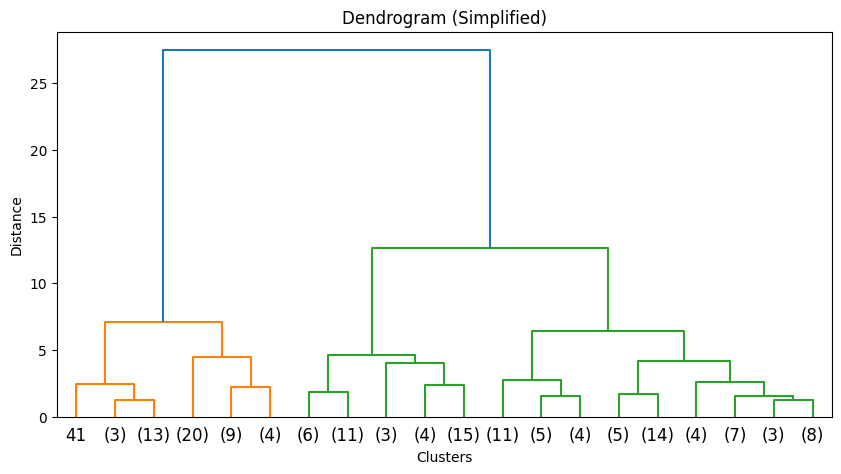

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_pca, method='ward')

plt.figure(figsize=(10, 5))

dendrogram(Z, truncate_mode='lastp', p=20)  # show only last 20 clusters

plt.title("Dendrogram (Simplified)")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

In [11]:
# Step 6: Apply Hierarchical Clustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_pca)

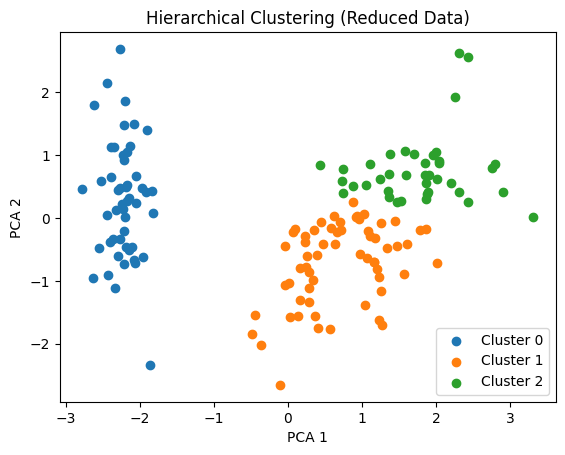

In [12]:
# Step 7: Visualize clusters
for i in range(3):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], label=f'Cluster {i}')

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Hierarchical Clustering (Reduced Data)")
plt.legend()
plt.show()

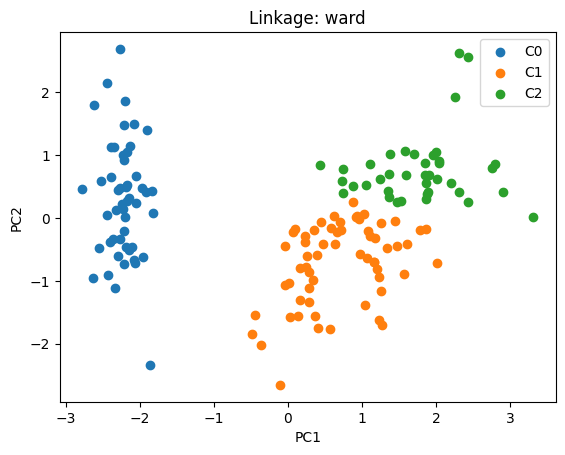

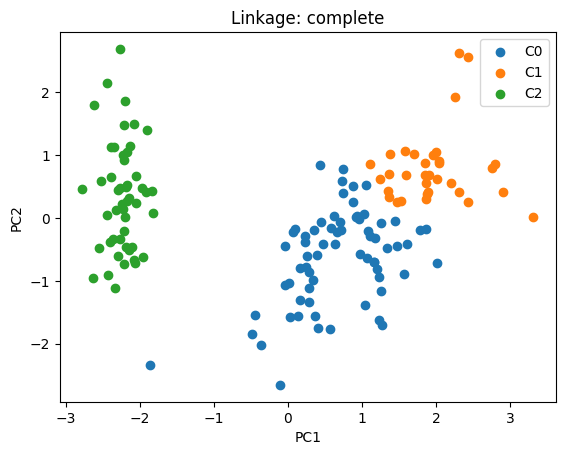

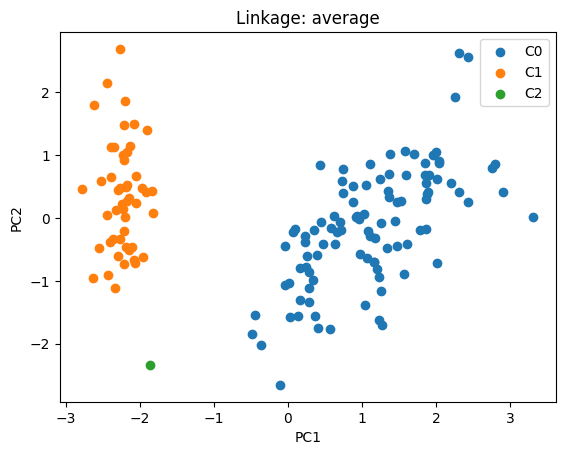

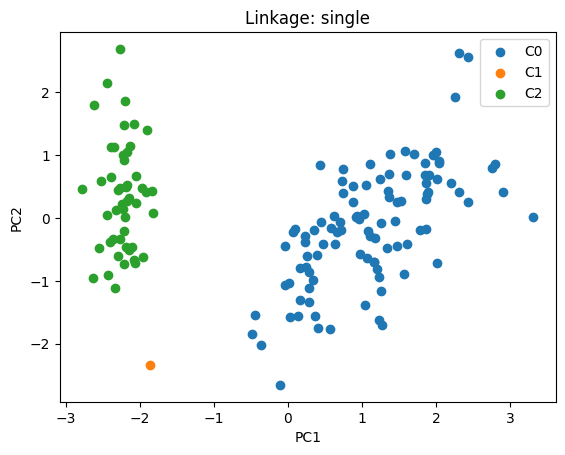

In [13]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

linkages = ['ward', 'complete', 'average', 'single']

for link in linkages:
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(X_pca)

    # Plot clusters
    for i in range(3):
        plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], label=f'C{i}')

    plt.title(f'Linkage: {link}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()

ward: 0.447
complete: 0.450
average: 0.480
single: 0.505


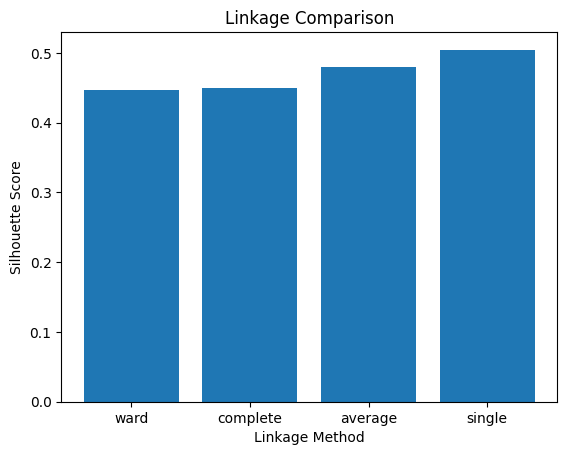

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

linkages = ['ward', 'complete', 'average', 'single']
scores = []

# Compute only silhouette score (enough for exam)
for link in linkages:
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)

    print(f"{link}: {score:.3f}")

# Plot
plt.bar(linkages, scores)
plt.xlabel("Linkage Method")
plt.ylabel("Silhouette Score")
plt.title("Linkage Comparison")

plt.show()